- Github repository: https://github.com/Simen03/simen03-ind320-app 
- Streamlit app: https://share.streamlit.io/?utm_source=streamlit&utm_medium=referral&utm_campaign=main&utm_content=-ss-streamlit-io-topright 

### AI usage

During the assignment I used Claude to help me break down the task to smaller tasks and to describe what I needed to do in some of the casses that I didn't understand how to solve on my own

I used the github copilot in VS code if I had some trouble with the code or something didn't work. I also used it to import the different libaries i needed. 



### Log

In this assignment I worked with reservoir data from a CSV file and used both Jupyter Notebook and Streamlit. Before this assignement I had used Jupiter notebook in some other courses, so I had no problems with this. On the other hand Streamlit was completely new to me. I started in the Jupyter Notebook by importing pandas and reading the data. I inspected the first rows and printed the column names to understand the structure of the dataset. 

The column names was in Nowergian and I therefore renamed the columns to clearer English names. I also converted the date column to a proper datetime format. After preparing the data I created separate line plots for the numerical columns over time. I removed columns that were not useful for the plots including the ISO year, ISO week, capacity, and region number. I then created a normalized plot where the selected numerical series were scaled to a range from 0 to 1. This made it easier to compare variables with different units and numerical ranges. During this process I learned that the dataset contains several regional observations for each date. Therefore the data had to be grouped by date before plotting to create continuous and meaningful time series.

The second part of the work was building the Streamlit application. I had no previous experience with Streamlit, so I had to learn how its page structure, widgets, caching, and charts work. I created four separate pages: a home page, a data table page, a plot page, and an extra test page. The table page displays one row for each relevant numerical column and uses LineChartColumn() to show the values from the first month. The plot page includes a dropdown menu for selecting one column or all columns and a slider for selecting a period of months. I used @st.cache_data so that the CSV file is not loaded unnecessarily every time the application reruns.

The main challenge was making the notebook analysis and the Streamlit app use the same column names and data preparation steps. I solved this by placing the loading and renaming logic in main.py. Overall, the assignment gave me practical experience with data cleaning, visualization, Jupyter Notebook, and the development of an interactive Streamlit application.

### Importing and looking on the data

In [5]:
# importing pandas library and reading the csv file
import pandas as pd

df = pd.read_csv('C:\\Users\\simen\\gitfiler\\IND320\\course_material\\D2Dbook\\data\\reservoirs.csv')

# displaying the first 5 rows of the dataframe and the column names to see how it looks like
print(df.head())
print(df.columns)

      dato_Id omrType  omrnr  iso_aar  iso_uke  fyllingsgrad  kapasitet_TWh  \
0  1995-09-03      EL      4     1995       35      0.944721      21.079208   
1  2020-11-15      EL      1     2020       46      0.974361       6.003264   
2  2011-08-28      EL      4     2011       34      0.786499      21.079208   
3  1998-07-05      EL      3     1998       27      0.793969       8.920932   
4  2011-03-27      EL      4     2011       12      0.300820      21.079208   

   fylling_TWh neste_Publiseringsdato  fyllingsgrad_forrige_uke  \
0    19.913979    0001-01-01T00:00:00                  0.936888   
1     5.849344    2020-11-25T13:00:00                  0.997406   
2    16.578772    0001-01-01T00:00:00                  0.787193   
3     7.082947    0001-01-01T00:00:00                  0.733812   
4     6.341054    0001-01-01T00:00:00                  0.311122   

   endring_fyllingsgrad  
0              0.007833  
1             -0.023046  
2             -0.000694  
3              0.0

### Renaming and looking at the new columns

In [6]:
# Renaming the columns to english and to have more descriptive names
df = df.rename(columns={
    'dato_Id': 'date_Id',
    'omrType': 'region_type',
    'omrnr': 'region_number',
    'iso_aar': 'iso_year',
    'iso_uke': 'iso_week',
    'fyllingsgrad': 'filling_percentage',
    'kapasitet_TWh': 'capacity_Twh',
    'fylling_TWh': 'filling_Twh',
    'neste_Publiseringsdato': 'next_publication_date',
    'fyllingsgrad_forrige_uke': 'filling_percentage_previous_week',
    'endring_fyllingsgrad': 'change_filling_percentage',
})

In [7]:
# Printing the first 10 rows of the dataframe to see how it looks like after renaming the columns
df.head(10)

,date_Id,region_type,region_number,iso_year,iso_week,filling_percentage,capacity_Twh,filling_Twh,next_publication_date,filling_percentage_previous_week,change_filling_percentage
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
5,2017-11-05,EL,4,2017,44,0.794520,21.079208,16.747847,0001-01-01T00:00:00,0.804085,-0.009565
6,2003-03-02,EL,1,2003,9,0.195046,6.003264,1.170914,0001-01-01T00:00:00,0.222014,-0.026968
7,2000-11-26,EL,4,2000,47,0.866371,21.079208,18.262426,0001-01-01T00:00:00,0.884963,-0.018591
8,2016-09-04,EL,1,2016,35,0.890967,6.003264,5.348708,0001-01-01T00:00:00,0.881946,0.009021
9,2023-08-13,EL,5,2023,32,0.836849,17.390587,14.553301,2023-08-23T13:00:00,0.776765,0.060084


### Plotting each columns first separately then all together

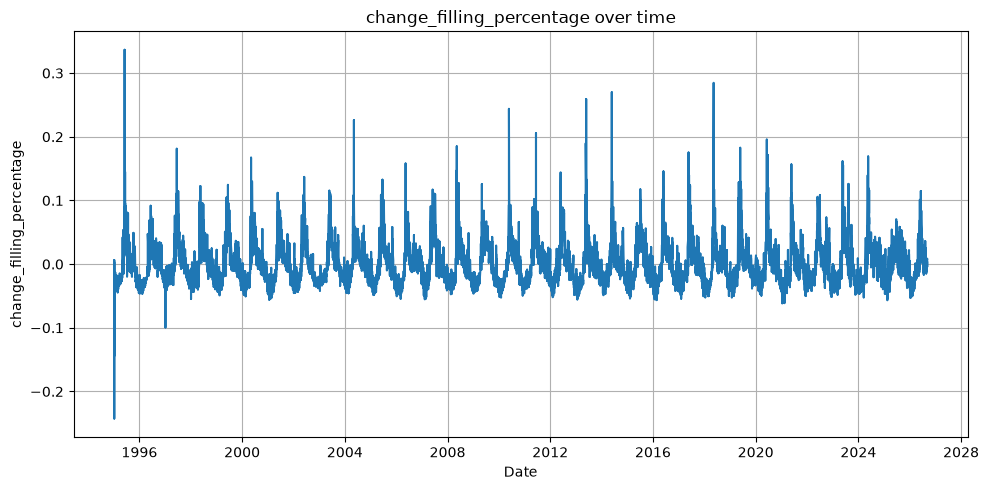

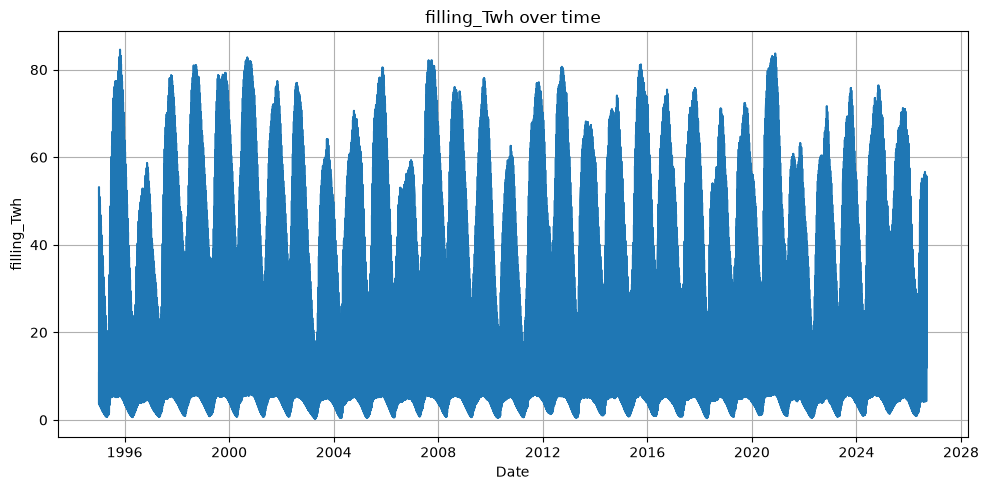

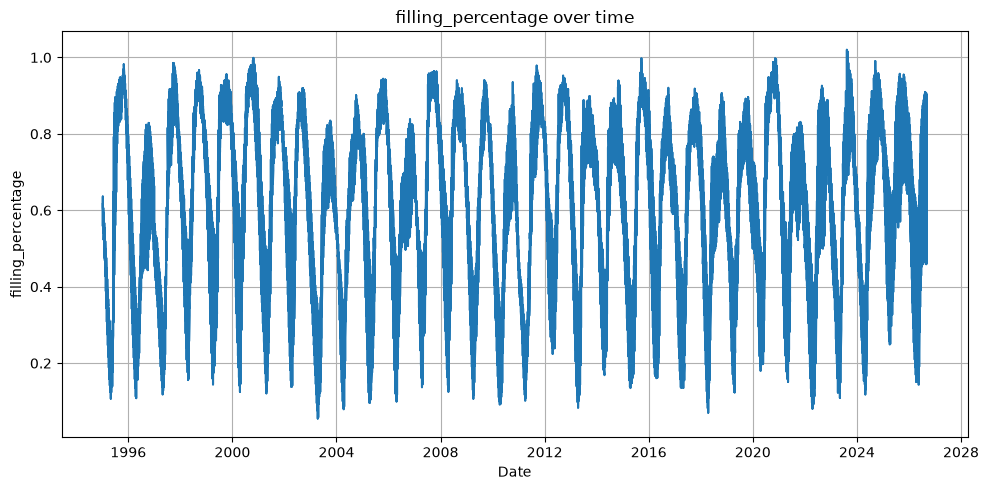

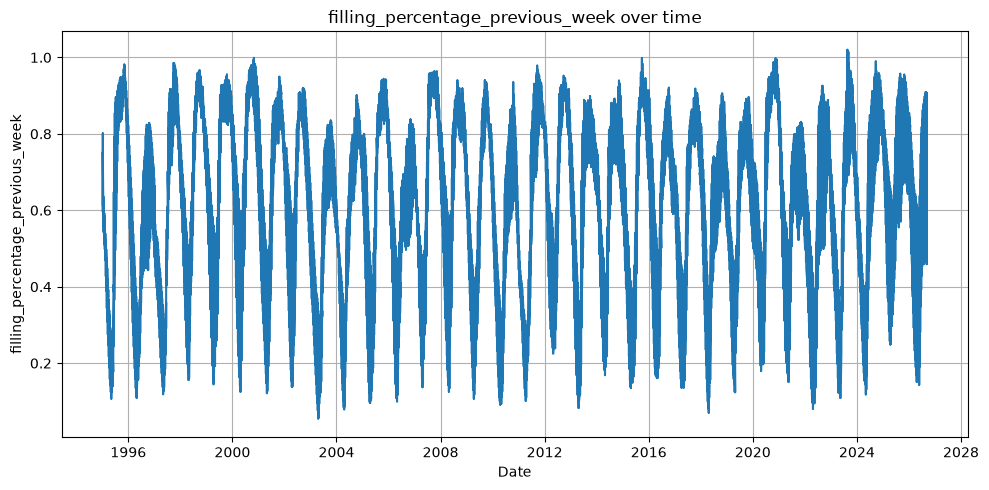

In [8]:
import matplotlib.pyplot as plt

# Making a plot of all numeric columns over time, with the x-axis being the date and the y-axis being the value of the numeric column
plot_df = df.copy()
date_column = 'date_Id' if 'date_Id' in plot_df.columns else 'dato_Id'
plot_df[date_column] = pd.to_datetime(plot_df[date_column])
plot_df = plot_df.sort_values(date_column)

numeric_columns = plot_df.select_dtypes(include='number').columns.difference(
    ['capacity_Twh', 'region_number', 'iso_year', 'iso_week']
)

# Iterating through each numeric column and creating a line plot for each one over time
for column in numeric_columns:
    plt.figure(figsize=(10, 5))
    plt.plot(plot_df[date_column], plot_df[column])
    plt.title(f'{column} over time')
    plt.xlabel('Date')
    plt.ylabel(column)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

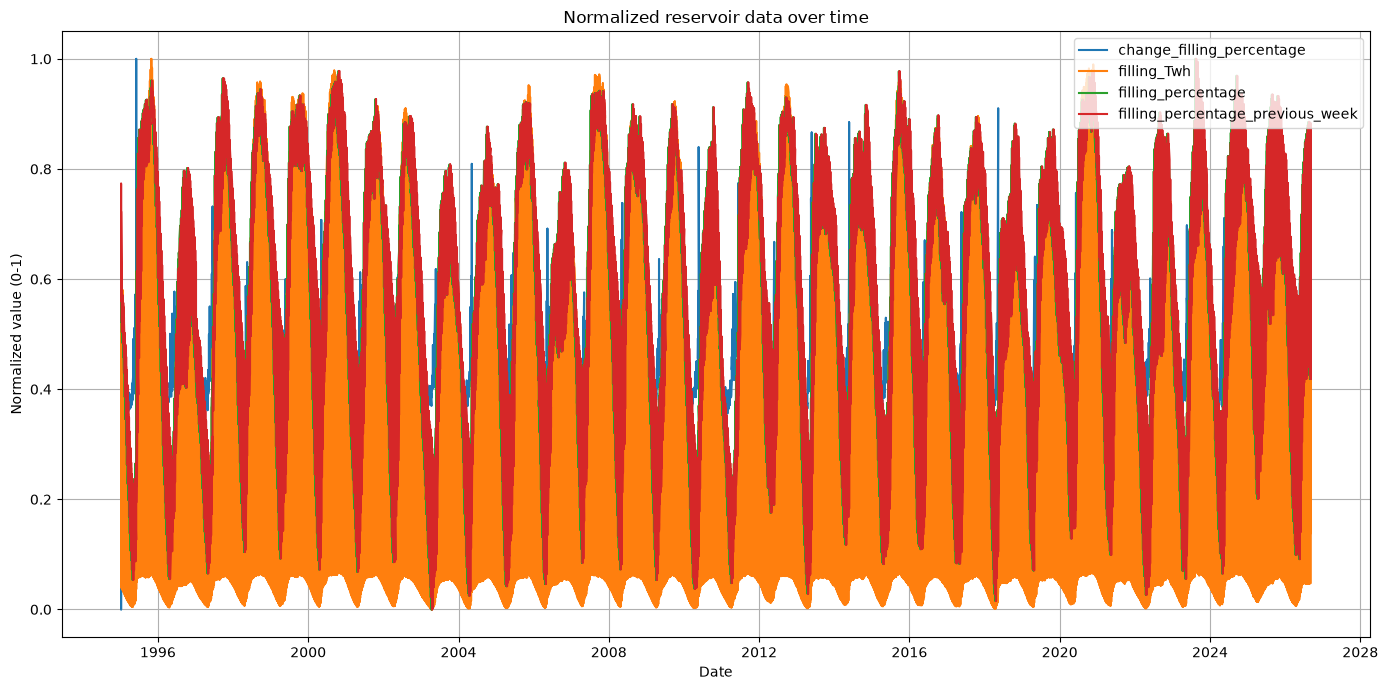

In [9]:
numeric_columns = df.select_dtypes(include='number').columns.difference(
    ['capacity_Twh', 'region_number', 'iso_year', 'iso_week']
)

# Normalizing the numeric columns to a range of 0 to 1 for better visualization
df_normalized = df[numeric_columns].copy()
df_normalized = (df_normalized - df_normalized.min()) / (
    df_normalized.max() - df_normalized.min()
)
df_normalized = df_normalized.fillna(0)

# Creating a line plot to visualize the normalized reservoir data over time
plot_df = df[['date_Id']].copy()
plot_df['date_Id'] = pd.to_datetime(plot_df['date_Id'])
plot_df = plot_df.join(df_normalized)
plot_df = plot_df.sort_values('date_Id')

# Plotting the normalized data
plt.figure(figsize=(14, 7))
for column in numeric_columns:
    plt.plot(plot_df['date_Id'], plot_df[column], label=column)

plt.title('Normalized reservoir data over time')
plt.xlabel('Date')
plt.ylabel('Normalized value (0-1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()